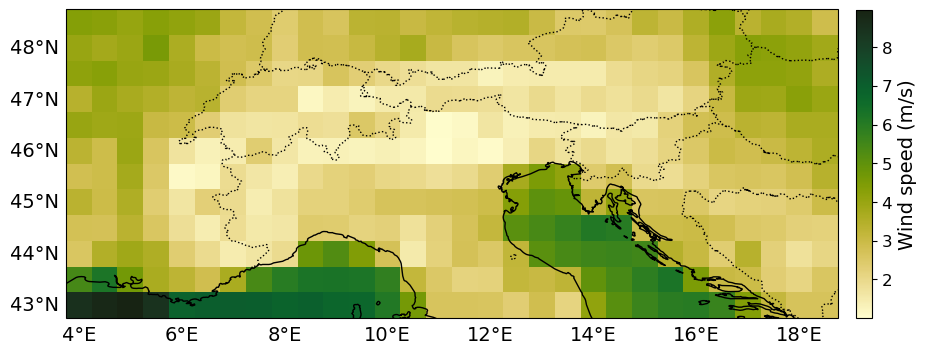

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import cmocean

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

output_path = "../plotting_data/0033_region.nc"
ds = xr.open_dataset(output_path)

# Extract wind speed data
data = ds["sfcWind"]

fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": ccrs.PlateCarree()})
data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.speed,
    cbar_kwargs={
        "label": "Wind speed (m/s)",
        "shrink": 0.8,
        "pad": 0.02,
    },
    rasterized=True,
)

# Add country borders
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.COASTLINE)

gl = ax.gridlines(draw_labels=True, linewidth=0)
gl.top_labels = False
gl.right_labels = False
ax.set_title("")
plt.savefig("../plot/0033_region.pdf", dpi=300, bbox_inches="tight")
plt.show()